<a href="https://colab.research.google.com/github/AleRR94/analisis-reposteria/blob/main/postres.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
# @title Análisis financiero de causa raíz sobre la erosión de márgenes en un negocio de repostería artesanal

import pandas as pd
df = pd.read_csv('datos_sensibilidad.csv')

df.head()

,ID,FechaDelPedido,Año,Mes,Producto,PV,CV,CantidadVendida,CantidadNoVendida,TotalCV,IT,Perdidas
0,ID-3824,2024-03-22,2024,3,Galletas chocochips,10.0,3.34,32,0,106.80,320.0,NaN
1,ID-3824,2024-03-29,2024,3,Galletas chocochips,10.0,3.34,64,0,213.60,640.0,
2,ID-3826,2024-04-05,2024,4,Brownie triple chocolate,20.0,7.10,18,0,127.87,360.0,NaN
3,ID-3827,2024-04-12,2024,4,Galletas danesas,7.0,2.62,35,0,91.82,245.0,NaN
4,ID-3824,2024-04-17,2024,4,Galletas chocochips,10.0,3.34,64,0,213.60,640.0,NaN


In [8]:
#Calcular promedio y la desviación estándar de la CantidadVendida por Producto
reporte_estabilidad = df.groupby('Producto')['CantidadVendida'].agg(['mean', 'std']).reset_index()

#Renombrar columnas
reporte_estabilidad.columns = ['Producto', 'Promedio_Ventas', 'Desv_Estandar_Ventas']

#Aplicar la fórmula del Coeficiente de Variación (Desviación / Promedio) * 100
reporte_estabilidad['Coeficiente_Variacion_%'] = (reporte_estabilidad['Desv_Estandar_Ventas'] / reporte_estabilidad['Promedio_Ventas']) * 100

#Redondear todo a 2 decimales
reporte_estabilidad = reporte_estabilidad.round(2)

#Ordenar del producto más inestable al más estable
reporte_estabilidad.sort_values(by='Coeficiente_Variacion_%', ascending=False)


,Producto,Promedio_Ventas,Desv_Estandar_Ventas,Coeficiente_Variacion_%
7,Muffins de yogurt,19.54,5.88,30.10
6,Muffin de chocolate,14.58,4.29,29.45
1,Brownie triple chocolate,19.43,5.56,28.64
3,Galletas chocochips,32.69,8.01,24.52
0,Besos de nuez,46.40,4.74,10.22
2,Flan de queso crema,16.83,1.33,7.90
4,Galletas danesas,32.68,1.99,6.07
5,Mini cheesecake,15.47,0.77,4.99


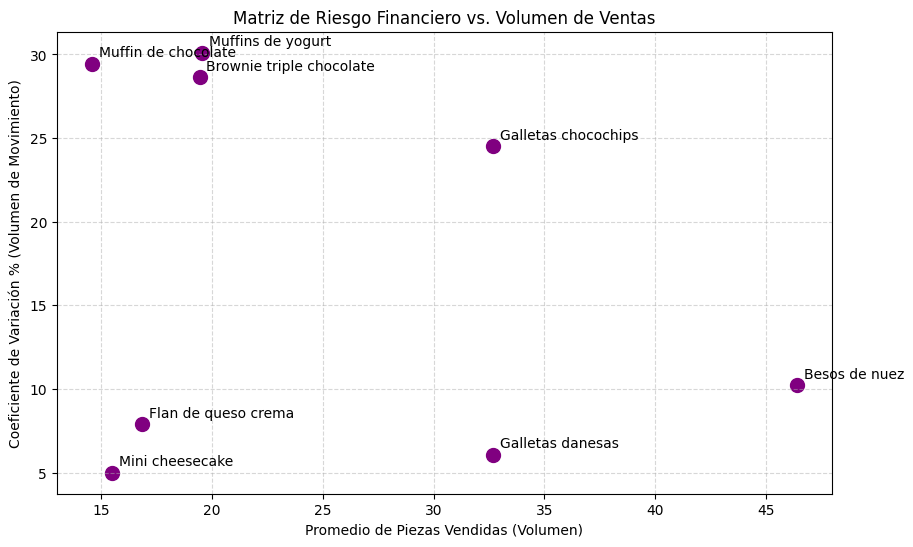

In [9]:
import matplotlib.pyplot as plt

# Gráfica para cruzar el Riesgo (Variación) contra las Ventas Reales
plt.figure(figsize=(10, 6))
plt.scatter(reporte_estabilidad['Promedio_Ventas'], reporte_estabilidad['Coeficiente_Variacion_%'], color='purple', s=100)

# Nombrar cada postre en la gráfica
for i, txt in enumerate(reporte_estabilidad['Producto']):
    plt.annotate(txt, (reporte_estabilidad['Promedio_Ventas'].iat[i], reporte_estabilidad['Coeficiente_Variacion_%'].iat[i]), xytext=(5,5), textcoords='offset points')

plt.title('Matriz de Riesgo Financiero vs. Volumen de Ventas')
plt.xlabel('Promedio de Piezas Vendidas (Volumen)')
plt.ylabel('Coeficiente de Variación % (Volumen de Movimiento)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()
